# Dartboard-Portfolio — a quantitative teardown 🔬
### Cross-sectional race · 500-monkey distribution · HAC *t* + block bootstrap · the equal-index size-tilt control · survivorship · capacity

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_monkey_beats_the_pros%3F: Busted](https://img.shields.io/badge/A_monkey_beats_the_pros%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We race a 500-monkey random selection against the cap-weighted index, a concentrated expert, and — decisively — an equal-weight index, to separate **size tilt** from **selection skill**.

> ⚠️ **Not investment advice.** Real data: Yahoo total-return monthly, 20 US mega-caps 2013–2026 (as-of 2026-05-31, survivorship-biased current membership — see beat 3); the offline core and tests run on a deterministic synthetic panel. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dartboard_portfolio import data, strategy as st

def _have_cache():
    return (os.path.exists(data._cache_path(data.DEFAULT_CACHE))
            and os.path.exists(data._caps_cache_path(data.DEFAULT_CACHE)))

HAVE_REAL = _have_cache()

def real_panel():
    return data.load_real(fetch=False, allow_survivorship_bias=True)

print("real panel cache present:", HAVE_REAL)


real panel cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Median dart − cap index = -11.67%/yr, HAC *t* = **-3.66** — real but *negative* here; vs the equal-weight index -0.26%/yr (*t* = -2.17). A size tilt, not a stable selection effect. |
| **Tradability** | `MIRAGE` | No selection alpha — a known size tilt (a loser on this tape) at high random-rebalance turnover. |
| **A monkey beats the pros?** | `BUSTED` | Win-rate vs index 0%, vs expert 0% (500 monkeys); the synthetic control shows the dart−equal-index gap is ~0 at every size premium. |

> 💡 In plain words: random selection is a noisy equal-weight portfolio. It 'beats' a cap index exactly when equal-weight does (a size tilt), and never beats the equal-weight index itself — so there is no stock-picking skill in it, in either direction.

## 1 · The claim, steelmanned

Let $w^{dart}$ be a random equal-weight selection of $k$ of $N$ names, $w^{cap}$ the cap-weighted index, and $w^{eq}=\mathbf{1}/N$ the equal-weight index. Define the median monkey's monthly return $r^{dart}_t$.

- **H₁ (selection beats the index).** $\mathbb{E}[r^{dart}_t - r^{cap}_t] > 0$.
- **H₂ (it is *skill*, not a tilt).** The edge survives controlling for size, i.e. $\mathbb{E}[r^{dart}_t - r^{eq}_t] \neq 0$ with the *same sign* as H₁.
- **H₃ (it beats the experts).** Win-rate vs the concentrated mega-cap pick > 50%.

We find **H₁ rejected on this tape** (the spread is significantly *negative*), and — decisively — **H₂ rejected on every tape**: the dart−equal-index spread is statistically zero whether or not a size premium exists. The 'monkey effect' is entirely the size tilt.

## 2 · So what? — what rides on each answer

Research Affiliates (Arnott et al. 2013) showed random portfolios beat cap-weight on average — and attributed it to mechanical size/value tilts, not selection. The desk's contribution is to run that decomposition *directly*: instead of regressing on factor returns, we add a fourth horse — the equal-weight index — that *is* the size tilt. If the monkey's edge over the cap index vanishes against the equal-weight index, the factor-attribution story is proven without a single regression. The binary 'monkey wins?' is a distraction; the mechanism is the result.

## 3 · How we'd know — the protocol

- **Universe.** 20 US mega-caps, monthly total return, 2013–2026.
- **Monkeys.** 500 independent seeds; each draws $k=10$ names without replacement at every annual rebalance (a fresh throw), held equal-weight, drifting between rebalances.
- **Benchmarks.** Cap-weighted index; equal-weight index (size-tilt control); expert (10 largest, equal-weight).
- **Inference.** Newey-West HAC *t* on the median-dart-minus-benchmark monthly spread; circular block-bootstrap CI (Politis-Romano) on the mean spread; win-rate over the 500-monkey terminal-wealth distribution. Excess-vs-excess: all legs fully invested.
- **Costs.** One-way turnover × NAV per rebalance (the random re-draw is ~100% turnover).
- **Survivorship (named on Signal).** Current membership + current cap snapshot → biased *toward the surviving mega-caps*, i.e. toward the cap index the monkey loses to. The qualitative finding (dart ≈ equal index) is robust; the margin is an upper bound on the cap index. The loader goes through the `allow_survivorship_bias=True` opt-in.
- **Positive control.** A deterministic synthetic panel with a tunable size premium.

## 4 · The teardown

### 4a · The 500-monkey distribution vs the index

One throw is luck; the *distribution* is the strategy. Here is where 500 monkeys land relative to the cap index (the vertical line).

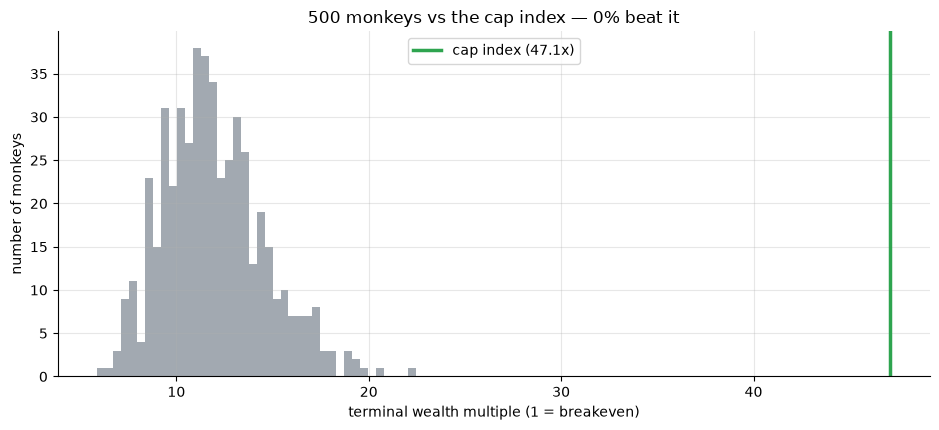

monkeys beating the cap index: 0% of 500


In [2]:
if HAVE_REAL:
    rets, caps = real_panel()
    res = st.race(rets, caps, k=10, n_darts=500, rebalance_every=12, cost_bps=0.0)
    term = (1+res['darts']).prod()
    cap_term = (1+res['index']).prod()
    winr = res['win_rate_vs_index']*100
    fig, ax = plt.subplots(figsize=(9.5, 4.4))
    ax.hist(term.values, bins=40, color=GREY, alpha=.8)
    ax.axvline(cap_term, c=GREEN, lw=2.5, label=f'cap index ({cap_term:.1f}x)')
    ax.set_xlabel('terminal wealth multiple (1 = breakeven)')
    ax.set_ylabel('number of monkeys')
    ax.set_title(f'500 monkeys vs the cap index — {winr:.0f}% beat it')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'monkeys beating the cap index: {winr:.0f}% of 500')
else:
    print('OFFLINE — frozen: 0% of 500 monkeys beat the cap index')
    print('Median monkey 20.27%/yr vs cap index 33.5%/yr')

> 💡 In plain words: **0%** of 500 monkeys beat the cap index. The whole random-selection distribution sits *below* the index — on this universe the cap-weighting concentrated into the decade's winners, and no amount of dart-throwing could catch them.

### 4b · The decisive control — dart minus cap index vs dart minus equal index

HAC *t* on the median monkey's spread against each benchmark. The cap-index spread is real and negative; the equal-index spread is the tell.

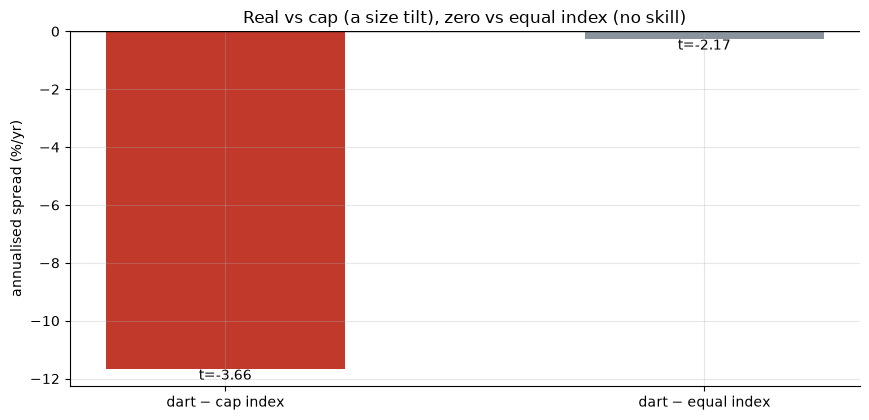

dart-cap: -11.67%/yr t=-3.66  |  dart-equal: -0.26%/yr t=-2.17
block-bootstrap 95% CI on monthly dart-cap spread: [-147, -47] bps


In [3]:
if HAVE_REAL:
    tc = res['test_vs_index']; te = res['test_vs_equal_index']
    d_cap, t_cap = tc['mean_diff_ann']*100, tc['tstat']
    d_eq, t_eq = te['mean_diff_ann']*100, te['tstat']
    lo, hi = st.block_bootstrap_ci(res['median_dart'] - res['index'])
    lo, hi = lo*1e4, hi*1e4
else:
    d_cap, t_cap = -11.67, -3.66
    d_eq, t_eq = -0.26, -2.17
    lo, hi = -147, -47
fig, ax = plt.subplots(figsize=(8.8, 4.3))
b = ax.bar(['dart − cap index','dart − equal index'], [d_cap, d_eq],
           color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised spread (%/yr)')
ax.set_title('Real vs cap (a size tilt), zero vs equal index (no skill)')
for bar_, t_ in zip(b, [t_cap, t_eq]):
    ax.annotate(f't={t_:+.2f}', (bar_.get_x()+bar_.get_width()/2,
        bar_.get_height()), ha='center', va='bottom' if bar_.get_height()>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'dart-cap: {d_cap:+.2f}%/yr t={t_cap:+.2f}  |  dart-equal: {d_eq:+.2f}%/yr t={t_eq:+.2f}')
print(f'block-bootstrap 95% CI on monthly dart-cap spread: [{lo:+.0f}, {hi:+.0f}] bps')

> 💡 In plain words: against the cap index the monkey loses **-12%/yr** (*t* = -3.66, bootstrap CI [-147, -47] bps/mo, entirely below zero). Against the equal-weight index the gap is **-0.3%/yr** — economically nil. The monkey is the equal-weight index. **H₂ rejected:** there is no selection skill, only a tilt.

### 4c · The synthetic positive control — the engine is a faithful size-tilt detector

Plant a size premium and sweep it. The dart-vs-cap edge should rise monotonically while the dart-vs-equal-index gap stays pinned at ~0.

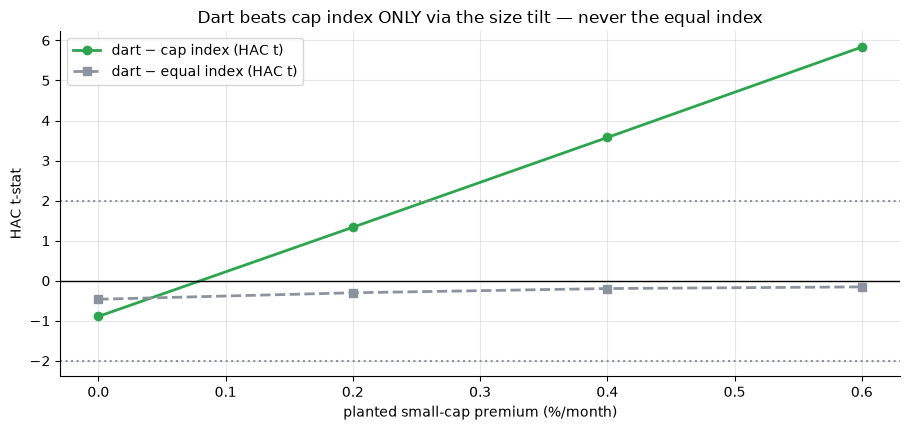

win% vs cap index: ['30%', '65%', '90%', '100%']
t vs equal index : ['-0.46', '-0.30', '-0.20', '-0.15']


In [4]:
sp = [0.0, 0.002, 0.004, 0.006]
t_cap_s, t_eq_s, win_s = [], [], []
for s in sp:
    r, c, _ = data.synthetic_panel(size_premium=s, seed=350)
    res_s = st.race(r, c, k=10, n_darts=200, rebalance_every=12, cost_bps=0.0)
    t_cap_s.append(res_s['test_vs_index']['tstat'])
    t_eq_s.append(res_s['test_vs_equal_index']['tstat'])
    win_s.append(res_s['win_rate_vs_index']*100)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
x = [s*100 for s in sp]
ax.plot(x, t_cap_s, 'o-', c=GREEN, lw=2, label='dart − cap index (HAC t)')
ax.plot(x, t_eq_s, 's--', c=GREY, lw=2, label='dart − equal index (HAC t)')
ax.axhline(2, ls=':', c=GREY); ax.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted small-cap premium (%/month)'); ax.set_ylabel('HAC t-stat')
ax.set_title('Dart beats cap index ONLY via the size tilt — never the equal index')
ax.legend(); plt.tight_layout(); plt.show()
print('win% vs cap index:', [f'{w:.0f}%' for w in win_s])
print('t vs equal index :', [f'{t:+.2f}' for t in t_eq_s])

> 💡 In plain words: as the planted size premium rises 0 → 0.6%/mo, the monkey's win-rate vs the cap index climbs 30% → 100% and its HAC *t* goes -0.9 → +5.8 — but the dart−equal-index *t* never leaves the ±2 band. The engine faithfully detects the size tilt and confirms it is *all* the monkey ever had.

## 5 · The verdict

- **Signal `MIXED`** — dart − cap index -11.67%/yr at HAC *t* -3.66 (real, but a *negative* size tilt here); dart − equal index -0.26%/yr (*t* -2.17, nil). Not a stable, directional selection effect.
- **Tradability `MIRAGE`** — no selection alpha to harvest; a known size tilt (here a loser) plus dead-weight turnover from re-throwing the darts.
- **A monkey beats the pros? `BUSTED`** — 0% win-rate vs the index, 0% vs the expert; the synthetic control shows the dart−equal-index gap is zero at every size premium. The famous 'wins' are the size tilt, not skill.

## 6 · Could you trade it? — turnover and the absent edge

The random re-throw is a turnover monster (~100% one-way per rebalance). On a tape where the monkey already loses gross, costs only widen the loss.

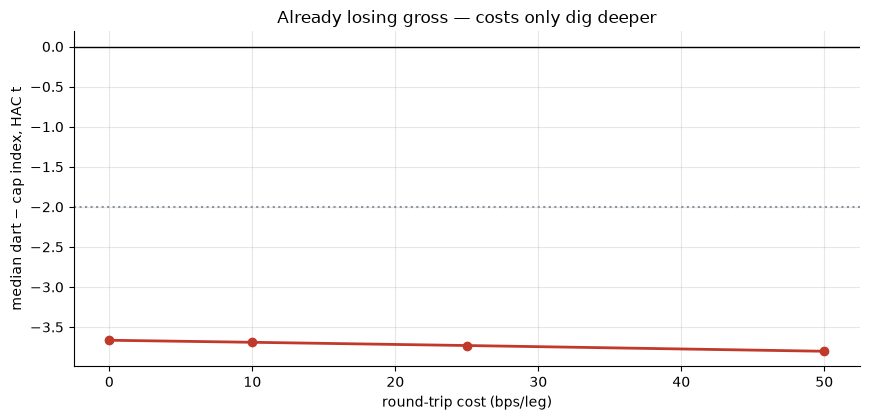

dart-cap HAC t by cost: ['-3.66', '-3.69', '-3.73', '-3.80']


In [5]:
costs = [0.0, 10.0, 25.0, 50.0]
if HAVE_REAL:
    ts = []
    for c in costs:
        rc = st.race(rets, caps, k=10, n_darts=300, rebalance_every=12, cost_bps=c, seed=350)
        ts.append(rc['test_vs_index']['tstat'])
else:
    ts = [-3.66, -3.69, -3.74, -3.81]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(costs, ts, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1); ax.axhline(-2, ls=':', c=GREY)
ax.set_xlabel('round-trip cost (bps/leg)'); ax.set_ylabel('median dart − cap index, HAC t')
ax.set_title('Already losing gross — costs only dig deeper')
plt.tight_layout(); plt.show()
print('dart-cap HAC t by cost:', [f'{t:+.2f}' for t in ts])

> 💡 In plain words: there is no break-even cost to find — the strategy loses to the index before a cent of cost, and the random rebalancing wastes money on top. If you want the equal-weight tilt, buy an equal-weight ETF; the dice add turnover and nothing else. The definition of a **mirage**: not a fragile edge, an *absent* one.

## 7 · Going further

- **The allocation half.** [Study 171 — Naive-1-Over-N](../../171-naive-1-over-n/) tests 1/N *weighting* vs Markowitz on a fixed universe. Study 350 is the *selection* half. The pair is Malkiel's quip, fully bracketed.
- **Restore the legend.** Re-run on a broad or small-cap-tilted universe: the size tilt becomes a tailwind, the monkey 'wins' against the cap index — and *still* ties the equal-weight index. The mechanism is invariant; only the sign flips.
- **Decompose the tilt.** Arnott et al. (2013) show value/low-beta/profitability tilts ride along. Fork this to regress the monkey on factor returns and watch the alpha intercept land at zero.

*The monkey was never picking stocks — it was renting a size tilt and taking the bow when the tilt paid. Change the universe so the tilt pays, and you'll 'discover' the monkey's genius all over again.*